# 12 CliqueSNV Parameter Sensitivity

**Methods mapping:** haplotype reconstruction parameter sensitivity.

This notebook summarizes the reconstructed G-gene haplotype counts obtained under the tested CliqueSNV `-tf` and `-t` settings and redraws Supplementary Fig. S3 from the sample-level parameter table.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPyImage

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('12_cliquesnv_parameter_sensitivity', ROOT)
INPUTS = {
    'sample_branch_combos': DATA_DIR / 'cliquesnv_parameter_sensitivity_sample_branch_combos.csv',
    'parameter_summary': DATA_DIR / 'cliquesnv_parameter_sensitivity_summary.csv',
    'run_status': DATA_DIR / 'cliquesnv_parameter_sensitivity_run_status.csv',
    'permutation_summary': DATA_DIR / 'cliquesnv_parameter_sensitivity_permutation_summary.csv',
}
OUTPUTS = {
    'haplotype_count_distribution': DATA_DIR / 'cliquesnv_haplotype_count_distribution.csv',
    'figure_png': FIG_DIR / 'Supplementary_Figure_S3_CliqueSNV_parameter_sensitivity.png',
    'figure_pdf': FIG_DIR / 'Supplementary_Figure_S3_CliqueSNV_parameter_sensitivity.pdf',
    'figure_svg': FIG_DIR / 'Supplementary_Figure_S3_CliqueSNV_parameter_sensitivity.svg',
}
display(pd.DataFrame({'input': INPUTS.keys(), 'path': [rel(p) for p in INPUTS.values()]}))
display(pd.DataFrame({'output': OUTPUTS.keys(), 'path': [rel(p) for p in OUTPUTS.values()]}))


,input,path
0,sample_branch_combos,data/processed_data/12_cliquesnv_parameter_sen...
1,parameter_summary,data/processed_data/12_cliquesnv_parameter_sen...
2,run_status,data/processed_data/12_cliquesnv_parameter_sen...
3,permutation_summary,data/processed_data/12_cliquesnv_parameter_sen...


,output,path
0,haplotype_count_distribution,data/processed_data/12_cliquesnv_parameter_sen...
1,figure_png,results/figures/12_cliquesnv_parameter_sensiti...
2,figure_pdf,results/figures/12_cliquesnv_parameter_sensiti...
3,figure_svg,results/figures/12_cliquesnv_parameter_sensiti...


## Read Parameter Tables

The sample-level table records the number of reconstructed haplotypes for each retained sample under each CliqueSNV setting.


In [3]:
combos = pd.read_csv(INPUTS['sample_branch_combos'])
summary = pd.read_csv(INPUTS['parameter_summary'])
run_status = pd.read_csv(INPUTS['run_status'])
permutation = pd.read_csv(INPUTS['permutation_summary'])

display(combos.head())
display(summary.head())
display(run_status[['project', 'project_label', 'param_id', 'status']].drop_duplicates().head(10))


,project,project_label,param_id,TreeCluster_threshold,SampleID,n_haplotypes,n_TreeCluster_branches,TreeCluster_combo,branches,total_frequency,is_cross_branch_sample,year_month,geo_stratum,stratum,virus_clade,collection_date,geographic_location
0,PRJNA1037681,Australia,TF002_T10,0.01,SRR26779971,2,2,C6+C9,C6+C9,1.0,True,2022-05,Sydney,2022-05|Sydney,A.D.3.1,2022/5/15,Australia: Sydney
1,PRJNA1037681,Australia,TF002_T10,0.01,SRR26779973,2,2,C9+Unclustered,C9+Unclustered,1.0,True,2022-07,Sydney,2022-07|Sydney,A.D.3.1,2022/7/14,Australia: Sydney
2,PRJNA1037681,Australia,TF002_T10,0.01,SRR26779974,3,3,C1+C6+C9,C1+C6+C9,1.0,True,2022-07,Sydney,2022-07|Sydney,A.D.3.1,2022/7/10,Australia: Sydney
3,PRJNA1037681,Australia,TF002_T10,0.01,SRR26779976,3,3,C1+C5+C9,C1+C5+C9,1.0,True,2022-07,Sydney,2022-07|Sydney,A.D.3.1,2022/7/8,Australia: Sydney
4,PRJNA1037681,Australia,TF002_T10,0.01,SRR26779980,2,2,C8+C9,C8+C9,1.0,True,2022-06,Sydney,2022-06|Sydney,A.D.3.1,2022/6/25,Australia: Sydney


,project,project_label,param_id,TreeCluster_threshold,n_samples,n_multi_haplotype_samples,n_cross_branch_samples,n_distinct_cross_branch_combos,dominant_combo,dominant_combo_samples,dominant_combo_fraction_of_cross_branch,tf,t,source
0,PRJNA1037681,Australia,TF002_T10,0.01,37,36,35,10,C9+Unclustered,15,0.428571,0.02,10,run
1,PRJNA1037681,Australia,TF003_T10_main,0.01,37,35,30,6,C4+C6,23,0.766667,0.03,10,existing_current_T10
2,PRJNA1037681,Australia,TF003_T15,0.01,37,33,29,9,C4+C10,8,0.275862,0.03,15,run
3,PRJNA1037681,Australia,TF003_T5_existing,0.01,37,27,27,1,C1+C2,27,1.000000,0.03,5,existing_old_T5
4,PRJNA1037681,Australia,TF005_T10,0.01,37,27,23,5,C5+Unclustered,9,0.391304,0.05,10,run


,project,project_label,param_id,status
0,PRJNA1037681,Australia,TF003_T15,cached
37,PRJNA1130896,United States,TF003_T15,cached
109,PRJNA1037681,Australia,TF002_T10,cached
146,PRJNA1130896,United States,TF002_T10,cached
218,PRJNA1037681,Australia,TF005_T10,cached
255,PRJNA1130896,United States,TF005_T10,cached


## Summarize Haplotype Counts

Haplotype counts are grouped into one, two, or at least three reconstructed haplotypes per sample.


In [4]:
order = ['TF002_T10', 'TF003_T5', 'TF003_T10_main', 'TF003_T15', 'TF005_T10']
combos['haplotype_count_group'] = np.where(combos['n_haplotypes'].le(1), '1', np.where(combos['n_haplotypes'].eq(2), '2', '3+'))
count_distribution = (
    combos.groupby(['project', 'project_label', 'param_id', 'haplotype_count_group'], observed=False)
    .size()
    .reset_index(name='n_samples')
)
count_distribution.to_csv(OUTPUTS['haplotype_count_distribution'], index=False)
display(count_distribution.head(15))


,project,project_label,param_id,haplotype_count_group,n_samples
0,PRJNA1037681,Australia,TF002_T10,1,1
1,PRJNA1037681,Australia,TF002_T10,2,29
2,PRJNA1037681,Australia,TF002_T10,3+,7
3,PRJNA1037681,Australia,TF003_T10_main,1,2
4,PRJNA1037681,Australia,TF003_T10_main,2,33
5,PRJNA1037681,Australia,TF003_T10_main,3+,2
6,PRJNA1037681,Australia,TF003_T15,1,4
7,PRJNA1037681,Australia,TF003_T15,2,31
8,PRJNA1037681,Australia,TF003_T15,3+,2
9,PRJNA1037681,Australia,TF003_T5_existing,1,10


## Figure

Supplementary Fig. S3 shows the fraction of samples with one, two, or at least three reconstructed G-gene haplotypes under each parameter setting.


/tmp/ipykernel_72872/3293479041.py:36: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  csub['param_id'] = pd.Categorical(csub['param_id'], order, ordered=True)
/tmp/ipykernel_72872/3293479041.py:36: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  csub['param_id'] = pd.Categorical(csub['param_id'], order, ordered=True)


Saved: results/figures/12_cliquesnv_parameter_sensitivity/Supplementary_Figure_S3_CliqueSNV_parameter_sensitivity.png, results/figures/12_cliquesnv_parameter_sensitivity/Supplementary_Figure_S3_CliqueSNV_parameter_sensitivity.pdf, results/figures/12_cliquesnv_parameter_sensitivity/Supplementary_Figure_S3_CliqueSNV_parameter_sensitivity.svg

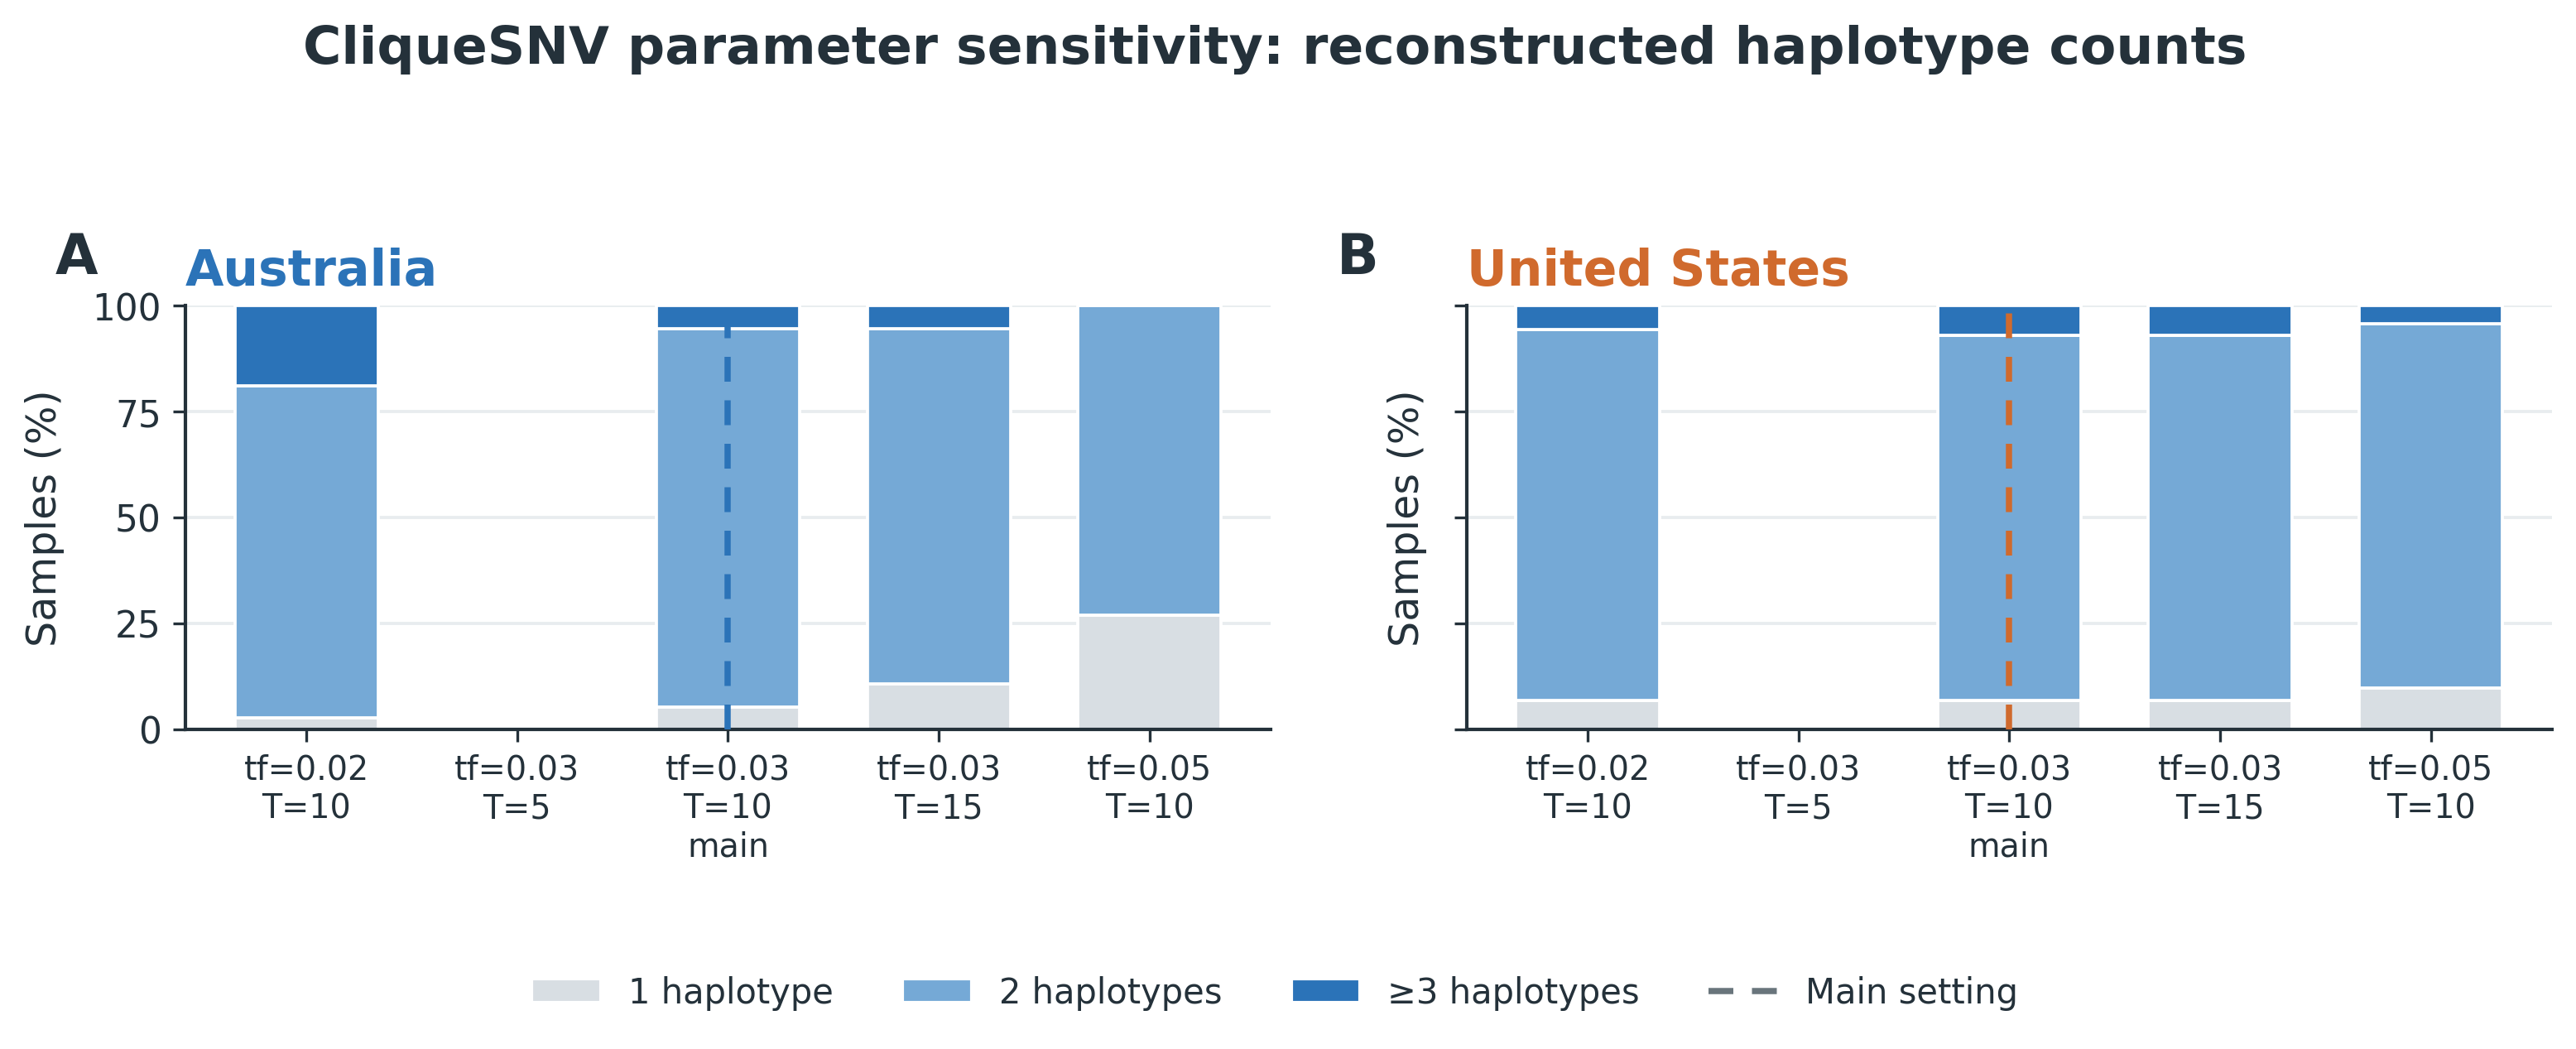

In [5]:
BLUE = '#2b73b8'
ORANGE = '#d06a2d'
DARK = '#24313a'
MID = '#69757c'
GRID = '#e8ecef'
COHORT_COLORS = {'Australia': BLUE, 'United States': ORANGE}

mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.linewidth': 1.0,
    'axes.edgecolor': DARK,
    'axes.labelcolor': DARK,
    'xtick.color': DARK,
    'ytick.color': DARK,
    'text.color': DARK,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
})

label_map = {
    'TF002_T10': 'tf=0.02\nT=10',
    'TF003_T5': 'tf=0.03\nT=5',
    'TF003_T10_main': 'tf=0.03\nT=10\nmain',
    'TF003_T15': 'tf=0.03\nT=15',
    'TF005_T10': 'tf=0.05\nT=10',
}
stack_colors = {'1': '#d8dee3', '2': '#75a9d6', '3+': '#2b73b8'}
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), dpi=300, sharey=True)
for ax, cohort, panel in zip(axes, ['Australia', 'United States'], ['A', 'B']):
    color = COHORT_COLORS[cohort]
    csub = combos[combos['project_label'].eq(cohort)].copy()
    csub['param_id'] = pd.Categorical(csub['param_id'], order, ordered=True)
    csub['hap_bin'] = np.where(csub['n_haplotypes'].le(1), '1', np.where(csub['n_haplotypes'].eq(2), '2', '3+'))
    counts = csub.groupby(['param_id', 'hap_bin'], observed=False).size().unstack(fill_value=0).reindex(order).reindex(columns=['1', '2', '3+'], fill_value=0)
    props = counts.div(counts.sum(axis=1), axis=0) * 100
    x = np.arange(len(order))
    bottom = np.zeros(len(order))
    for cat in ['1', '2', '3+']:
        vals = props[cat].to_numpy()
        ax.bar(x, vals, bottom=bottom, width=0.68, color=stack_colors[cat], edgecolor='white', linewidth=0.9, label=f"{cat} haplotype{'s' if cat != '1' else ''}")
        bottom += vals
    main_idx = order.index('TF003_T10_main')
    ax.axvline(main_idx, color=color, linestyle=(0, (4, 3)), linewidth=1.8, zorder=5)
    ax.set_xticks(x)
    ax.set_xticklabels([label_map[o] for o in order], fontsize=9.5)
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_ylabel('Samples (%)', fontsize=11.8, labelpad=8)
    ax.set_title(cohort, loc='left', color=color, fontsize=14.4, fontweight='bold')
    ax.text(-0.12, 1.05, panel, transform=ax.transAxes, fontsize=16, fontweight='bold', ha='left', va='bottom')
    ax.grid(axis='y', color=GRID, linewidth=0.9, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='y', labelsize=10.5)
    ax.set_axisbelow(True)
handles = [
    mpl.patches.Patch(facecolor=stack_colors['1'], edgecolor='white', label='1 haplotype'),
    mpl.patches.Patch(facecolor=stack_colors['2'], edgecolor='white', label='2 haplotypes'),
    mpl.patches.Patch(facecolor=stack_colors['3+'], edgecolor='white', label='≥3 haplotypes'),
    mpl.lines.Line2D([], [], color=MID, linestyle=(0, (4, 3)), linewidth=1.8, label='Main setting'),
]
fig.legend(handles=handles, frameon=False, fontsize=10.0, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.005))
fig.suptitle('CliqueSNV parameter sensitivity: reconstructed haplotype counts', fontsize=15.2, fontweight='bold', y=0.98)
fig.tight_layout(rect=(0.02, 0.14, 0.99, 0.92), w_pad=2.4)
paths = au.save_pub_figure(fig, FIG_DIR, 'Supplementary_Figure_S3_CliqueSNV_parameter_sensitivity', dpi=600)
display(Markdown('Saved: ' + ', '.join(paths.values())))
plt.show()
